In [1]:
# SNIPPET 8.7 CREATING A SYNTHETIC DATASET
import pandas as pd
import numpy as np
import random
from sklearn.datasets import make_classification
def getTestData(n_features=40,n_informative=10,n_redundant=10,n_samples=10000):
    # generate a random dataset for a classification problem
    from sklearn.datasets import make_classification
    trnsX,cont=make_classification(n_samples=n_samples,n_features=n_features,
                                   n_informative=n_informative,n_redundant=n_redundant,random_state=0,
                                   shuffle=False)

    trnsX,cont = pd.DataFrame(trnsX), pd.Series(cont).to_frame('bin')
    df0=['I_'+str(i) for i in range(n_informative)]+\
        ['R_'+str(i) for i in range(n_redundant)]
    df0+=['N_'+str(i) for i in range(n_features-len(df0))]
    trnsX.columns=df0
    cont['w']=1./cont.shape[0]
    cont['t1']=pd.Series(cont.index,index=cont.index)
    return trnsX,cont

In [2]:
# Generate data
trnsX, cont = getTestData(n_features=40, n_informative=10, n_redundant=10, n_samples=2000)

I've dropped n_samples to 2000 and generally set cv = 5 to keep processing under 1 hour

In [4]:
# SNIPPET 8.2 MDI FEATURE IMPORTANCE

def featImpMDI(fit,featNames):
    # feat importance based on IS mean impurity reduction
    df0={i:tree.feature_importances_ for i,tree in enumerate(fit.estimators_)}
    df0=pd.DataFrame.from_dict(df0,orient='index')
    df0.columns=featNames
    df0=df0.replace(0,np.nan) # because max_features=1
    imp=pd.concat({'mean':df0.mean(),'std':df0.std()*df0.shape[0]**-0.5},axis=1)
    imp/=imp['mean'].sum()
    return imp

In [5]:
#SNIPPET 7.2 DV Class with Overlap
from sklearn.model_selection import KFold
from typing import Optional, Tuple, Generator, Any
class PurgedKFold(KFold):
    """
    Extend KFold class to work with labels that span intervals.
    The train is purged of observations overlapping test-label intervals.
    Test set is assumed to be contiguous (shuffle=False), without training samples in between.
    """

    def __init__(self, n_splits: int = 3, t1: Optional[pd.Series] = None, pctEmbargo=0.0) -> None:
        if not isinstance(t1, pd.Series) and t1 is not None:
            raise ValueError("t1 must be a pd.Series")
        super(PurgedKFold, self).__init__(n_splits, shuffle=False, random_state=None)
        self.t1 = t1
        self.pctEmbargo = pctEmbargo

    def split(self, X: pd.DataFrame, y: Optional[pd.Series] = None, groups: Optional[pd.Series] = None) -> Generator[Tuple[np.ndarray, np.ndarray], None, None]:
        if (X.index==self.t1.index).sum() != len(self.t1):
            raise ValueError("X and t1 must have the same index")
        indices = np.arange(X.shape[0])
        mbrg = int(X.shape[0] * self.pctEmbargo)
        test_starts = [(i[0], i[-1] + 1) for i in np.array_split(np.arange(X.shape[0]), self.n_splits)]
        for i, j in test_starts:
            t0 =self.t1.index[i]
            test_indices = indices[i:j]
            maxT1Idx = self.t1.index.searchsorted(self.t1[test_indices].max())
            train_indices = self.t1.index.searchsorted(self.t1[self.t1 <= t0].index)
            if maxT1Idx < X.shape[0]:
                train_indices = np.concatenate((train_indices, indices[maxT1Idx + mbrg:]))
            yield train_indices, test_indices

In [6]:
# SNIPPET 8.3 MDA FEATURE IMPORTANCE

def featImpMDA(clf,X,y,cv,sample_weight,t1,pctEmbargo,scoring='neg_log_loss'):
    # feat importance based on OOS score reduction
    if scoring not in ['neg_log_loss','accuracy']:
        raise Exception('wrong scoring method.')
    from sklearn.metrics import log_loss, accuracy_score
    cvGen=PurgedKFold(n_splits=cv,t1=t1,pctEmbargo=pctEmbargo) # purged cv
    scr0,scr1=pd.Series(),pd.DataFrame(columns=X.columns)
    for i,(train,test) in enumerate(cvGen.split(X=X)):
        X0,y0,w0=X.iloc[train,:],y.iloc[train],sample_weight.iloc[train]
        X1,y1,w1=X.iloc[test,:],y.iloc[test],sample_weight.iloc[test]
        fit=clf.fit(X=X0,y=y0,sample_weight=w0.values)
        if scoring=='neg_log_loss':
            prob=fit.predict_proba(X1)
            scr0.loc[i]=-log_loss(y1,prob,sample_weight=w1.values,
                                 labels=clf.classes_)
        else:
            pred=fit.predict(X1)
            scr0.loc[i]=accuracy_score(y1,pred,sample_weight=w1.values)
        for j in X.columns:
            X1_=X1.copy(deep=True)
            np.random.shuffle(X1_[j].values) # permutation of a single column
            if scoring=='neg_log_loss':
                prob=fit.predict_proba(X1_)
                scr1.loc[i,j]=-log_loss(y1,prob,sample_weight=w1.values,
                                       labels=clf.classes_)
            else:
                pred=fit.predict(X1_)
                scr1.loc[i,j]=accuracy_score(y1,pred,sample_weight=w1.values)
    imp=(-scr1).add(scr0,axis=0)
    if scoring=='neg_log_loss':imp=imp/-scr1
    else:imp=imp/(1.-scr1)
    imp=pd.concat({'mean':imp.mean(),'std':imp.std()*imp.shape[0]**-0.5},axis=1)
    return imp,scr0.mean()

In [7]:
# SNIPPET 8.4 IMPLEMENTATION OF SFI

def auxFeatImpSFI(featNames,clf,trnsX,cont,scoring,cvGen):
    imp=pd.DataFrame(columns=['mean','std'])
    for featName in featNames:
        df0=cvScore(clf,X=trnsX[[featName]],y=cont['bin'],sample_weight=cont['w'],
                   scoring=scoring,cvGen=cvGen)
        imp.loc[featName,'mean']=df0.mean()
        imp.loc[featName,'std']=df0.std()*df0.shape[0]**-0.5
    return imp

In [8]:
#SNIPPET 7.4 Using the PurgedKFold Class
# necessary to avoid gugs with "classes_" and 'sample_weight' attributes in some sklearn implementation
from sklearn.metrics import log_loss, accuracy_score
def cvScore(
    clf: Any, X: pd.DataFrame, y: pd.Series, sample_weight: Optional[pd.Series] = None, scoring: str = 'neg_log_loss',
    t1: Optional[pd.Series] = None, cv: Optional[int] = None,
    cvGen: Optional[PurgedKFold] = None, pctEmbargo: float = None) -> np.ndarray:
    """
    Compute the cross-validated score of a classifier

        Parameters:
            clf : Any: classifier object
            X : pd.DataFrame: feature set
            y : pd.Series: labels

        Returns:
            score np.ndarray: array with cross-validated scores
    """
    if scoring not in ['neg_log_loss', 'accuracy']:
        raise ValueError("scoring must be 'neg_log_loss' or 'accuracy'")
    if cvGen is None:
       cvGen = PurgedKFold(n_splits=cv, t1=t1, pctEmbargo=pctEmbargo)
    score = []
    for train, test in cvGen.split(X=X):
        fit = clf.fit(X.iloc[train], y.iloc[train], sample_weight=sample_weight.iloc[train].values)
        if scoring == 'neg_log_loss':
            prob = fit.predict_proba(X.iloc[test, :])
            score_ = -log_loss(y.iloc[test], prob, sample_weight=sample_weight.iloc[test].values, labels=clf.classes_)
        else:
            pred = fit.predict(X.iloc[test, :])
            score_ = accuracy_score(y.iloc[test], pred, sample_weight=sample_weight.iloc[test].values)
        score.append(score_) 
    return np.array(score)

In [9]:
# SNIPPET 8.8 CALLING FEATURE IMPORTANCE FOR ANY METHOD

def featImportance(trnsX,cont,n_estimators=1000,cv=10,max_samples=1.,numThreads=16,
                  pctEmbargo=0,scoring='accuracy',method='SFI',min_weight_fraction_leaf=0., ensemble='bagging'):
    # feature importance from a random forest
    from sklearn.tree import DecisionTreeClassifier
    from sklearn.ensemble import BaggingClassifier
    from sklearn.ensemble import RandomForestClassifier

    n_jobs=(-1 if numThreads>1 else 1) # run 1 thread with ht_helper in direct
    #1) prepare classifier,cv: max_features=1, to prevent masking
    if ensemble!='bagging':
        clf=DecisionTreeClassifier(criterion='entropy',max_features=1,
                                class_weight='balanced',min_weight_fraction_leaf=min_weight_fraction_leaf)
        clf=BaggingClassifier(estimator=clf,n_estimators=n_estimators, max_features=1.0,
                            max_samples=max_samples, oob_score=True,n_jobs=n_jobs)
    else:
        clf=RandomForestClassifier(n_estimators=n_estimators,criterion='entropy',
                                    min_weight_fraction_leaf=min_weight_fraction_leaf,
                                    max_features=1.0,oob_score=True,n_jobs=n_jobs,
                                    max_samples=max_samples)

    fit=clf.fit(X=trnsX,y=cont['bin'],sample_weight=cont['w'].values)
    oob=clf.oob_score_

    if method=='MDI':
        imp=featImpMDI(fit,featNames=trnsX.columns)
        oos=cvScore(clf,X=trnsX,y=cont['bin'],cv=cv,sample_weight=cont['w'],
                   t1=cont['t1'],pctEmbargo=pctEmbargo,scoring=scoring).mean()
    elif method=='MDA':
        imp,oos=featImpMDA(clf,X=trnsX,y=cont['bin'],cv=cv,sample_weight=cont['w'],
                          t1=cont['t1'],pctEmbargo=pctEmbargo,scoring=scoring)
    elif method=='SFI':
        cvGen=PurgedKFold(n_splits=cv,t1=cont['t1'],pctEmbargo=pctEmbargo)
        oos=cvScore(clf,X=trnsX,y=cont['bin'],sample_weight=cont['w'],scoring=scoring,
                   cvGen=cvGen).mean()
        imp = auxFeatImpSFI(featNames=trnsX.columns,clf=clf,trnsX=trnsX,cont=cont,scoring=scoring,cvGen=cvGen)
    
    return imp,oob,oos

In [10]:
# SNIPPET 8.10 FEATURE IMPORTANCE PLOTTING FUNCTION
import matplotlib.pyplot as plt

def plotFeatImportance(imp,oob,oos,method,tag='test_func',simNum=None):
    # plot mean imp bars with std
    # Filter out NaN values to avoid plotting warnings
    imp = imp.dropna()
    
    if imp.empty:
        print(f"Warning: No valid importance values to plot for {method}")
        return
    
    fig, ax = plt.subplots(figsize=(10,imp.shape[0]/5.))
    imp=imp.sort_values('mean',ascending=True)
    ax.barh(imp.index,imp['mean'],xerr=imp['std'],align='center',color='b',alpha=0.25,ecolor='black')
    if method=='MDI':
        ax.set_xlim(left=0, right=imp.sum(axis=1).max())
        ax.axvline(1.0 /imp.shape[0], linewidth=1, color='r', linestyle='dotted')
    ax.get_yaxis().set_visible(False)
    for i,j in zip(ax.patches,imp.index):
                ax.text(i.get_width()/2,
                i.get_y()+i.get_height()/2, j, ha='center',va='center', color='black')
    ax.set_title('%s | Feature Importance (%s) OOB: %.4f OOS: %.4f'%(tag,method,oob,oos))
    plt.show()
    return

In [11]:
# SNIPPET 8.9 CALLING ALL COMPONENTS

def testFunc(n_features=40,n_informative=10,n_redundant=10,n_estimators=1000,
            n_samples=10000,cv=5):
    # test the performance of the feat importance functions on artificial data
    # Nr noise features = n_features-n_informative-n_redundant
    from itertools import product
    #trnsX,cont=getTestData(n_features,n_informative,n_redundant,n_samples)
    dict0={'minWLeaf':[0.],'scoring':['accuracy'],'method':['MDI','MDA','SFI'],
          'max_samples':[1.]}
    jobs=[dict(zip(dict0,i)) for i in product(*dict0.values())]
    for job in jobs:
        job['simNum']=job['method']+'_'+job['scoring']+'_'+'%.2f'%job['minWLeaf']+ \
                     '_'+str(job['max_samples'])
        print(job['simNum'])

        imp,oob,oos=featImportance(trnsX=trnsX,cont=cont,n_estimators=n_estimators,cv=cv,method=job['method'],
                                   scoring=job['scoring'],min_weight_fraction_leaf=job['minWLeaf'],max_samples=job['max_samples'])
        plotFeatImportance(imp=imp,oob=oob,oos=oos,method=job['method'],tag='testFunc',simNum=job['simNum'])
    return

MDI_accuracy_0.00_1.0


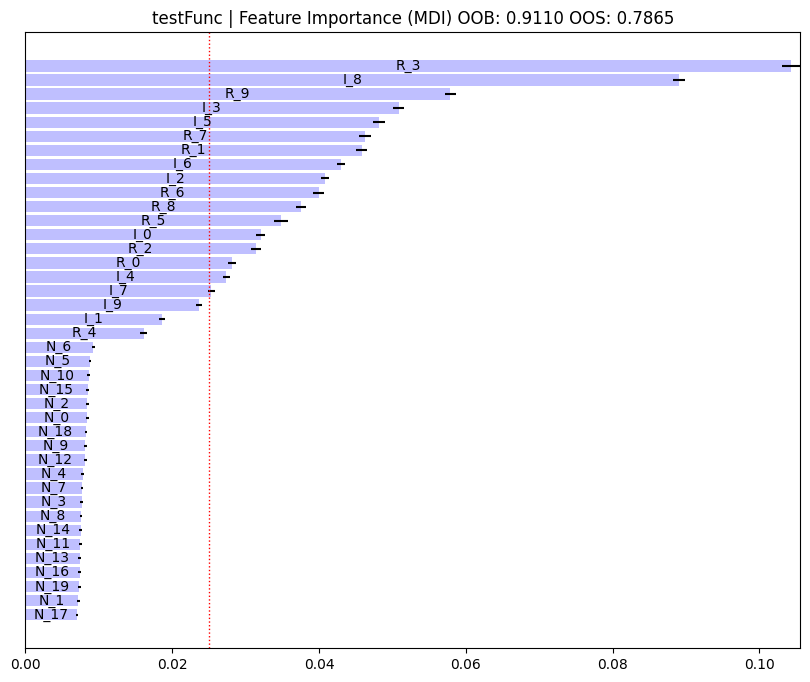

MDA_accuracy_0.00_1.0


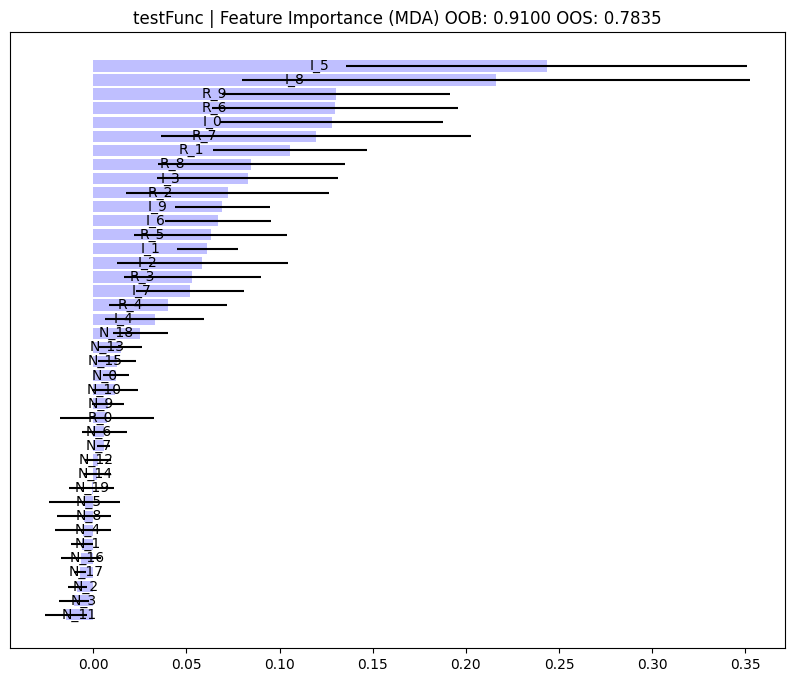

SFI_accuracy_0.00_1.0


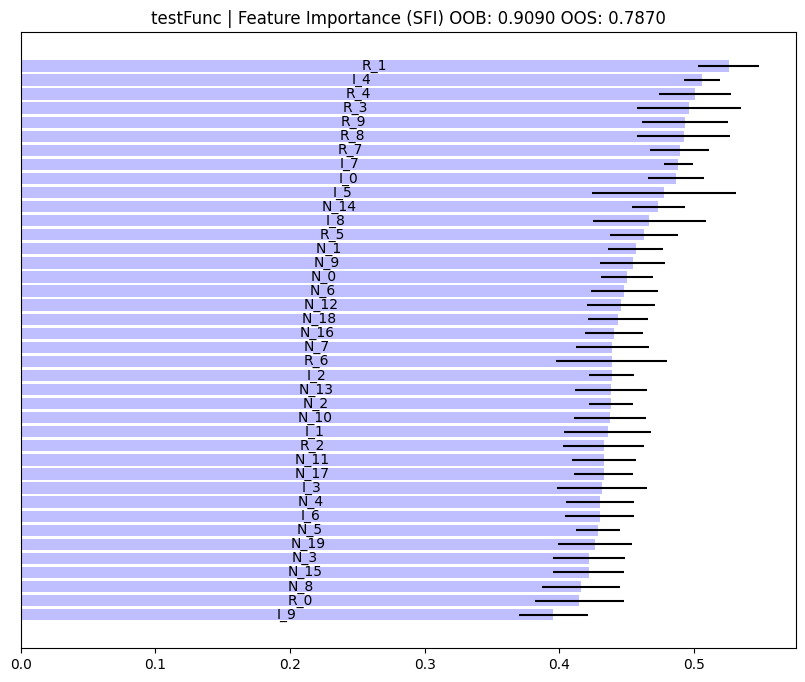

In [12]:
testFunc()

# Question 1
### (b)	Apply a PCA transformation on X, which we denote by X_dot

### (c)	Compute MDI, MDA, and SFI feature importance on (X_dot,y ), where the base estimator is RF.

Original features: 40, PCA components: 40
Explained variance ratio (first 10 components): [0.32019603 0.1862021  0.1301957  0.10718942 0.05974109 0.04435366
 0.02394283 0.01725703 0.01295524 0.00777624]
MDI_accuracy_0.00_1.0


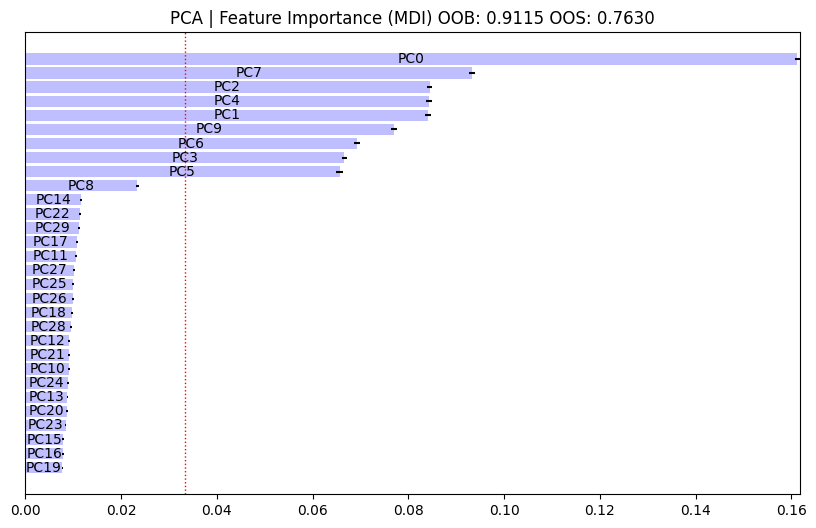

MDA_accuracy_0.00_1.0


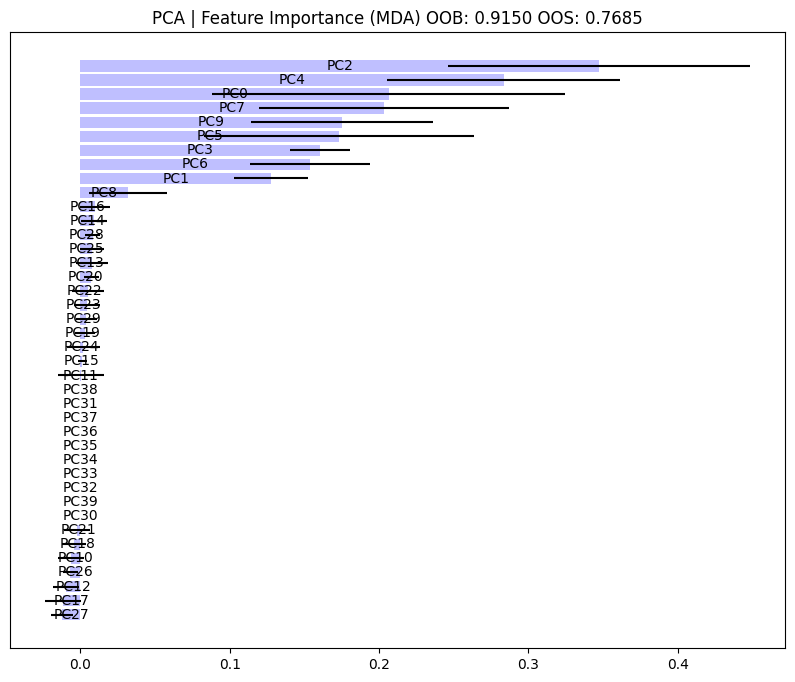

SFI_accuracy_0.00_1.0


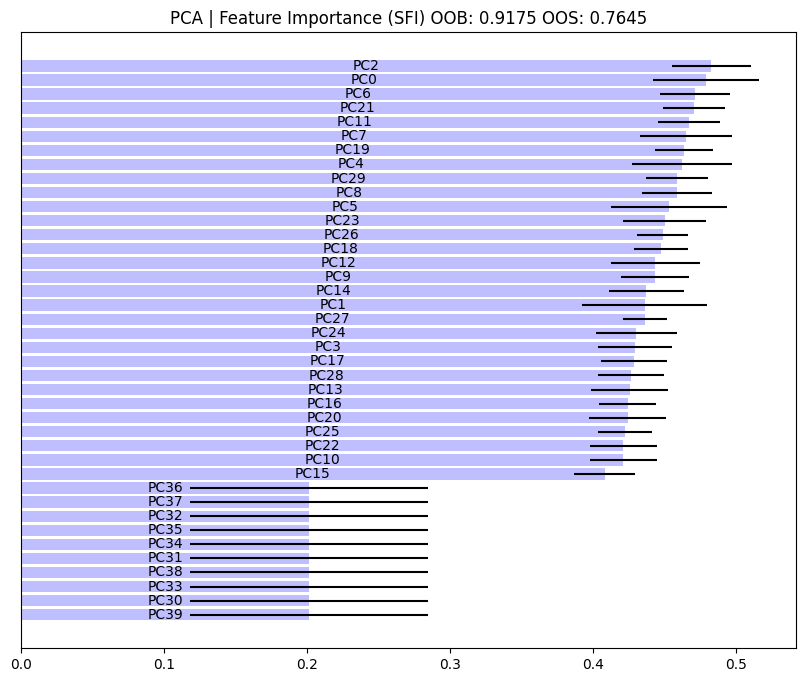

In [13]:
# Apply PCA transformation and compute feature importance on PCA components
from sklearn.decomposition import PCA
from itertools import product

# Apply PCA transformation to get X_dot 
pca = PCA()
X_dot = pca.fit_transform(trnsX)
X_dot = pd.DataFrame(X_dot, columns=[f'PC{i}' for i in range(X_dot.shape[1])], index=trnsX.index)

print(f"Original features: {trnsX.shape[1]}, PCA components: {X_dot.shape[1]}")
print(f"Explained variance ratio (first 10 components): {pca.explained_variance_ratio_[:10]}")

# Now compute feature importance on PCA-transformed data
n_estimators = 1000
cv = 5
dict0 = {'minWLeaf': [0.], 'scoring': ['accuracy'], 'method': ['MDI', 'MDA', 'SFI'], 'max_samples': [1.]}
jobs = [dict(zip(dict0, i)) for i in product(*dict0.values())]

for job in jobs:
    job['simNum'] = job['method'] + '_' + job['scoring'] + '_' + '%.2f' % job['minWLeaf'] + '_' + str(job['max_samples'])
    print(job['simNum'])
    
    imp, oob, oos = featImportance(trnsX=X_dot, cont=cont, n_estimators=n_estimators, cv=cv, method=job['method'],
                                   scoring=job['scoring'], min_weight_fraction_leaf=job['minWLeaf'], max_samples=job['max_samples'])
    plotFeatImportance(imp=imp, oob=oob, oos=oos, method=job['method'], tag='PCA', simNum=job['simNum'])

### (d)	Do the three methods agree on what features are important? 

No - 

MDI - PC0, PC7, PC2, PC4

MDA - PC2, PC4, PC0, PC7

SFI - PC2, PC0, PC6, PC21

PC0 and PC2 is selected in top 4 in all methods.


### Why?

MDI (Mean Decrease in Impurity) measures how much each feature reduces impurity (e.g., Gini) when building trees. It's computed in-sample during training and tends to favor high-cardinality and continuous features. **PC features are uncorrelated**.


MDA (Mean Decrease in Accuracy) measures the drop in out-of-sample predictive performance when a feature is randomly shuffled. It directly tests predictive importance. **I'd expect PC to appear in order**.


SFI (Single Feature Importance) measures how well each feature performs alone in out-of-sample prediction. It captures individual predictive power but misses interaction effects and synergies between features. **I'd expect PC to apprear in order, PC21?**


In essence: MDI reflects in-sample splits, MDA reflects marginal predictive contribution when removed, and SFI reflects standalone predictive ability. Rankings differ because a feature can be important for splitting (MDI), redundant with others (low MDA), yet predictive alone (high SFI), or vice versa.

# Question 2
### Generate a new dataset (X_dd,y ), where X_dd is a feature union of trnsX and X_dot

(a)	Compute MDI, MDA, and SFI feature importance on (X_dd,y ), where the base estimator is RF.

Original features: 40
PCA components: 40
Combined features (X_dd): 80
Feature list (first 10): ['I_0', 'I_1', 'I_2', 'I_3', 'I_4', 'I_5', 'I_6', 'I_7', 'I_8', 'I_9']
MDI_accuracy_0.00_1.0


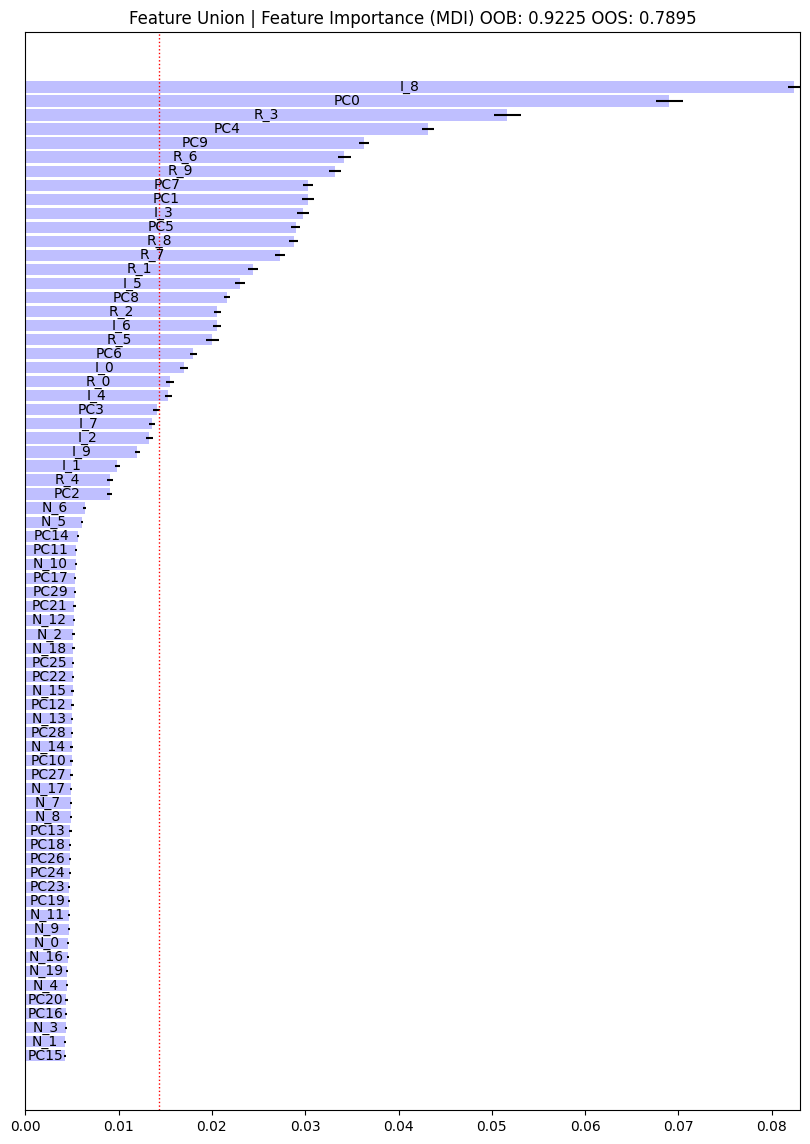

  Top feature for MDI: I_8 (importance: 0.082383)
MDA_accuracy_0.00_1.0


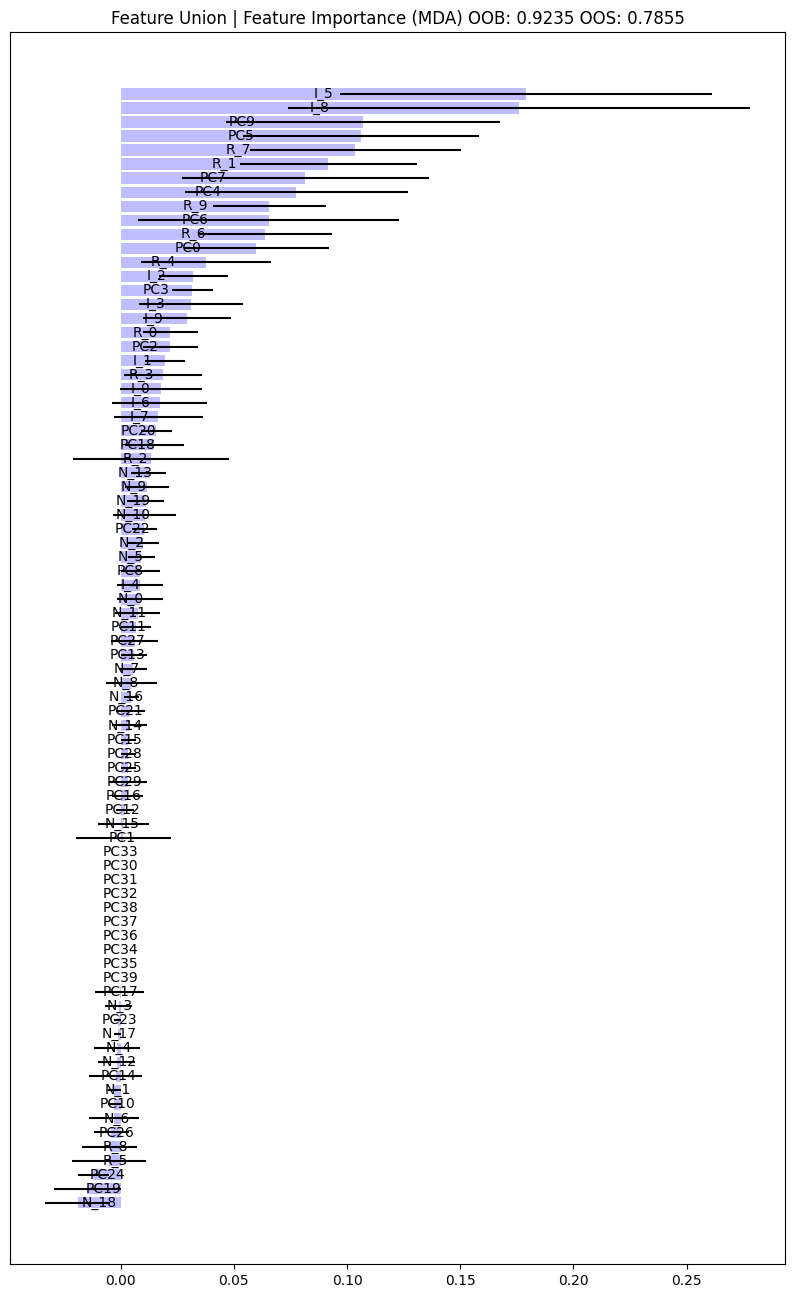

  Top feature for MDA: I_5 (importance: 0.178943)
SFI_accuracy_0.00_1.0


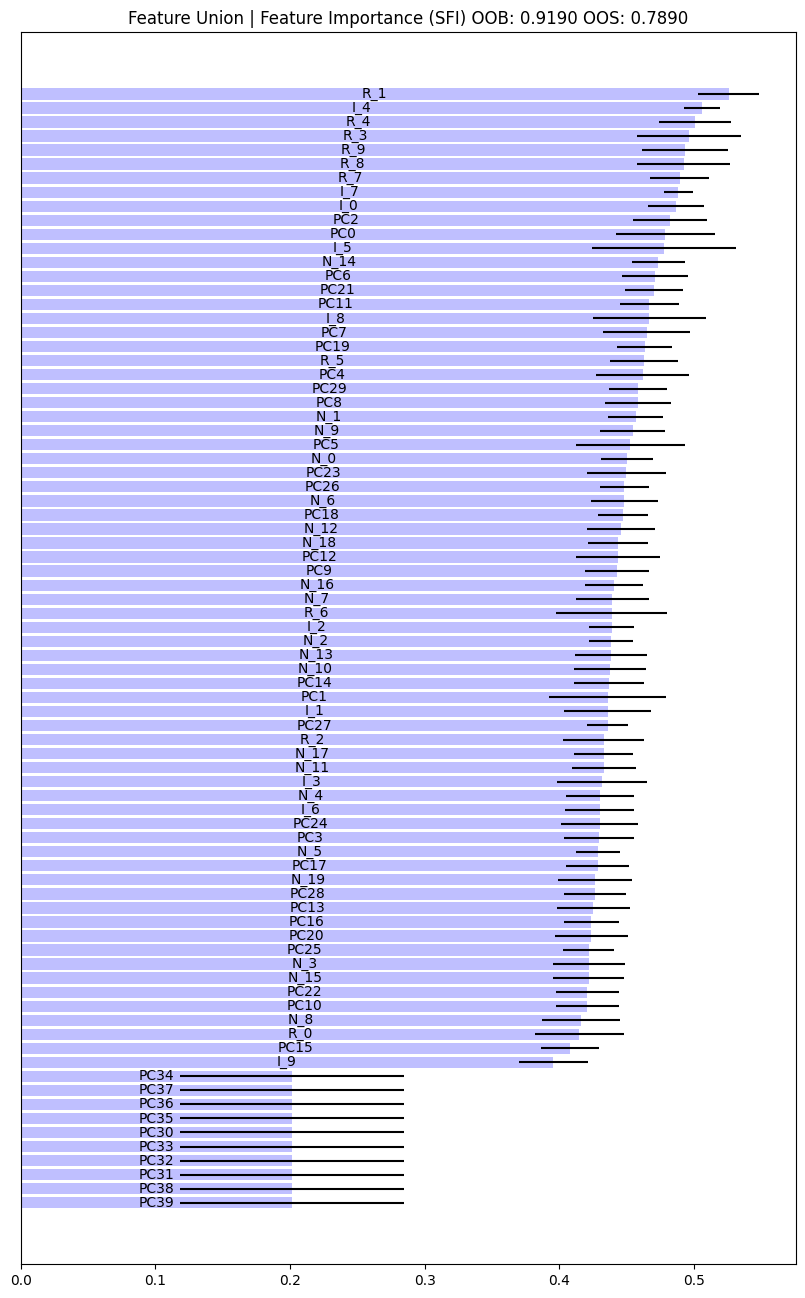

  Top feature for SFI: R_1 (importance: 0.526000)

Top features identified: {'MDI': 'I_8', 'MDA': 'I_5', 'SFI': 'R_1'}


In [14]:
# Feature Union: Combine original features and PCA components
from itertools import product

# Create X_dd as feature union of trnsX and X_dot
X_dd = pd.concat([trnsX, X_dot], axis=1)

print(f"Original features: {trnsX.shape[1]}")
print(f"PCA components: {X_dot.shape[1]}")
print(f"Combined features (X_dd): {X_dd.shape[1]}")
print(f"Feature list (first 10): {list(X_dd.columns[:10])}")

# Compute feature importance on combined dataset and extract top features
n_estimators = 1000
cv = 5
dict0 = {'minWLeaf': [0.], 'scoring': ['accuracy'], 'method': ['MDI', 'MDA', 'SFI'], 'max_samples': [1.]}
jobs = [dict(zip(dict0, i)) for i in product(*dict0.values())]

# Store top features for later use in drop analysis
top_features = {}

for job in jobs:
    job['simNum'] = job['method'] + '_' + job['scoring'] + '_' + '%.2f' % job['minWLeaf'] + '_' + str(job['max_samples'])
    print(job['simNum'])
    
    imp, oob, oos = featImportance(trnsX=X_dd, cont=cont, n_estimators=n_estimators, cv=cv, method=job['method'],
                                   scoring=job['scoring'], min_weight_fraction_leaf=job['minWLeaf'], max_samples=job['max_samples'])
    plotFeatImportance(imp=imp, oob=oob, oos=oos, method=job['method'], tag='Feature Union', simNum=job['simNum'])
    
    # Extract top feature for this method if not already captured
    if job['method'] not in top_features:
        imp_clean = imp.dropna().copy()
        if not imp_clean.empty:
            imp_clean['mean'] = pd.to_numeric(imp_clean['mean'], errors='coerce')
            imp_clean = imp_clean.dropna()
            if not imp_clean.empty:
                top_feat = imp_clean['mean'].idxmax()
                top_features[job['method']] = top_feat
                print(f"  Top feature for {job['method']}: {top_feat} (importance: {imp_clean.loc[top_feat, 'mean']:.6f})")

print(f"\nTop features identified: {top_features}")

## (b)	Do the three methods agree on the important features? 

No - 

MDI - I_8, PC0, R_3, PC4

MDA - I_5, I_8, PC9, PC5

SFI - R_1, I_4, R_4, R_3

For SFI PC sigal seems week on the combined set.

Noise features are filtered to the bottom.

### Why?

MDI (Mean Decrease in Impurity) measures how much each feature reduces impurity (e.g., Gini) when building trees. It's computed in-sample during training and tends to favor high-cardinality and continuous features. **It can be biased by correlated features**.


MDA (Mean Decrease in Accuracy) measures the drop in out-of-sample predictive performance when a feature is randomly shuffled. It directly tests predictive importance but **can underestimate correlated features since shuffling one may leave predictive information in its correlates**.


SFI (Single Feature Importance) **measures how well each feature performs alone in out-of-sample prediction**. It captures individual predictive power but misses interaction effects and synergies between features.


In essence: MDI reflects in-sample splits, MDA reflects marginal predictive contribution when removed, and SFI reflects standalone predictive ability. Rankings differ because a feature can be important for splitting (MDI), redundant with others (low MDA), yet predictive alone (high SFI), or vice versa.

## Drop Most Important Features

Drop the top feature identified by each method (MDI, MDA, SFI) and recompute feature importance on the reduced datasets.

In [15]:
# Use top_features dict from Feature Union cell to create reduced datasets
# (No need to recompute - we already have the top features from the Feature Union cell above)

print("Using top features from Feature Union cell:")
print(f"Top features: {top_features}")
print()

Using top features from Feature Union cell:
Top features: {'MDI': 'I_8', 'MDA': 'I_5', 'SFI': 'R_1'}



Original X_dd shape: (2000, 80)
X_dd_no_MDI shape (dropped I_8): (2000, 79)
X_dd_no_MDA shape (dropped I_5): (2000, 79)
X_dd_no_SFI shape (dropped R_1): (2000, 79)

Computing feature importance on Drop_Top_MDI dataset
MDI_accuracy_0.00_1.0


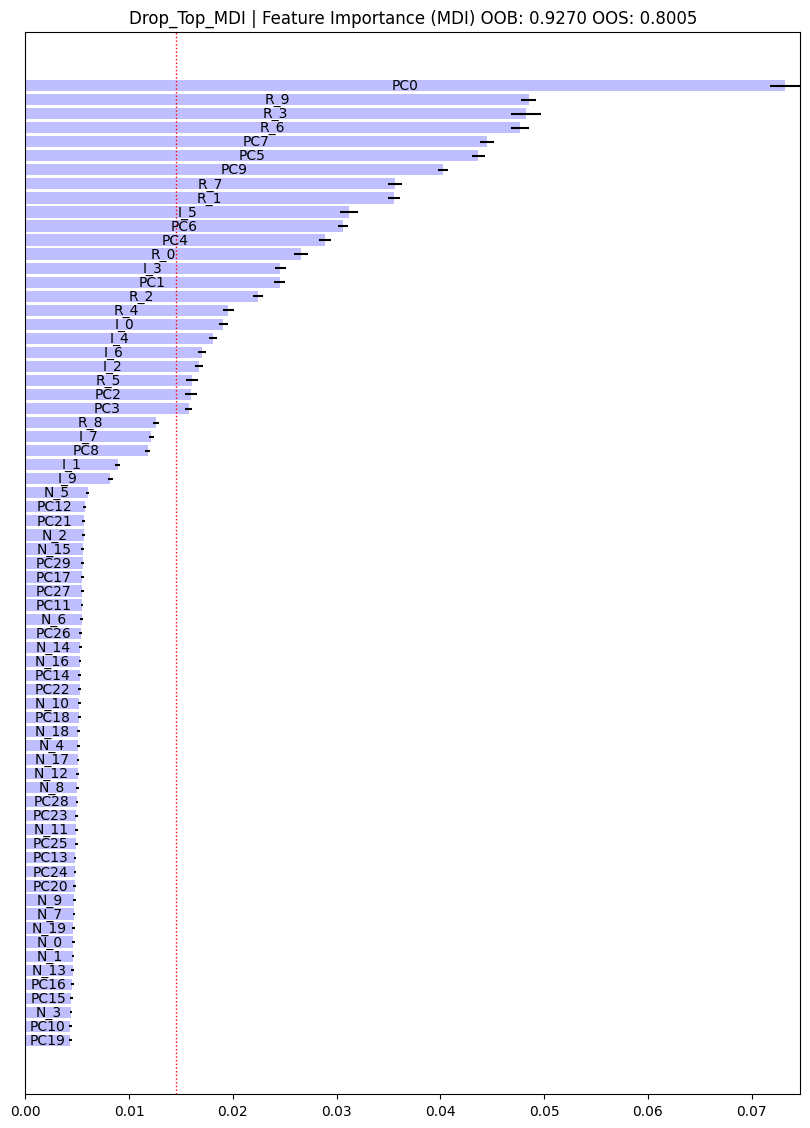

MDA_accuracy_0.00_1.0


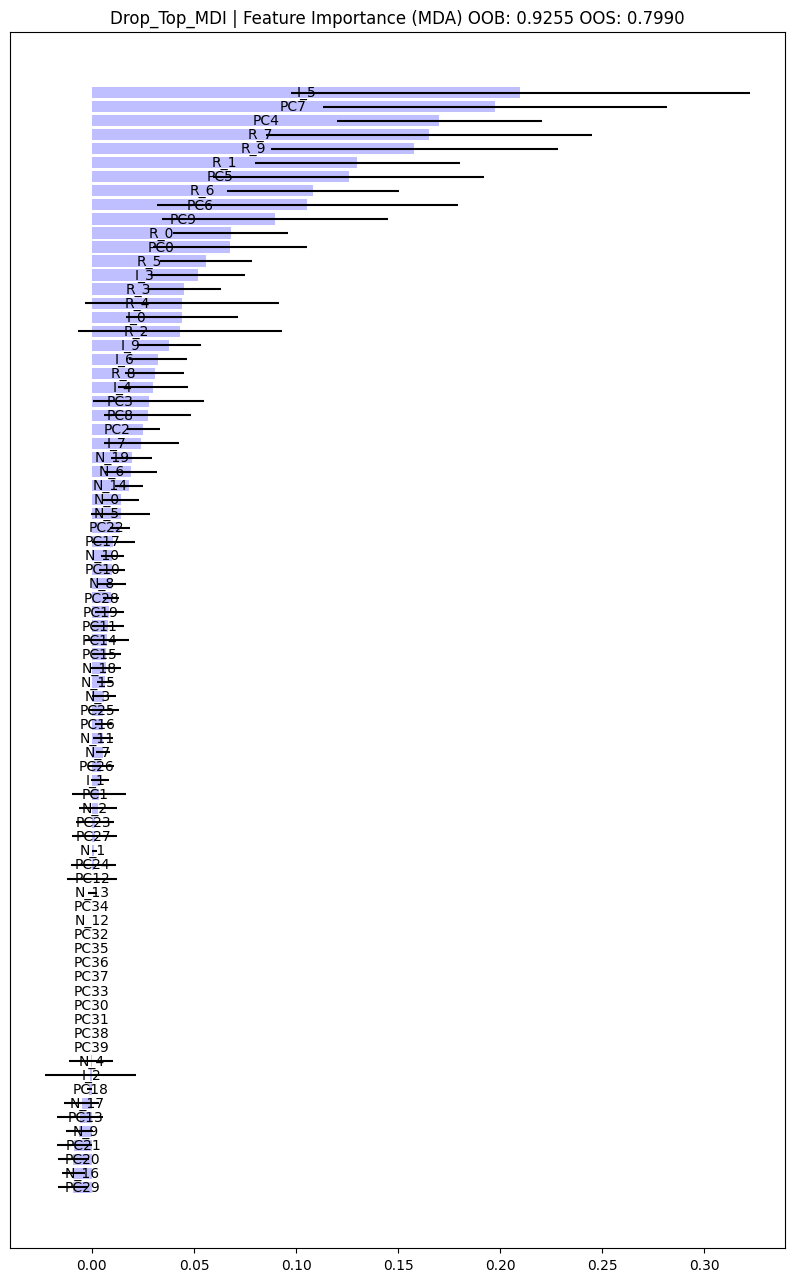

SFI_accuracy_0.00_1.0


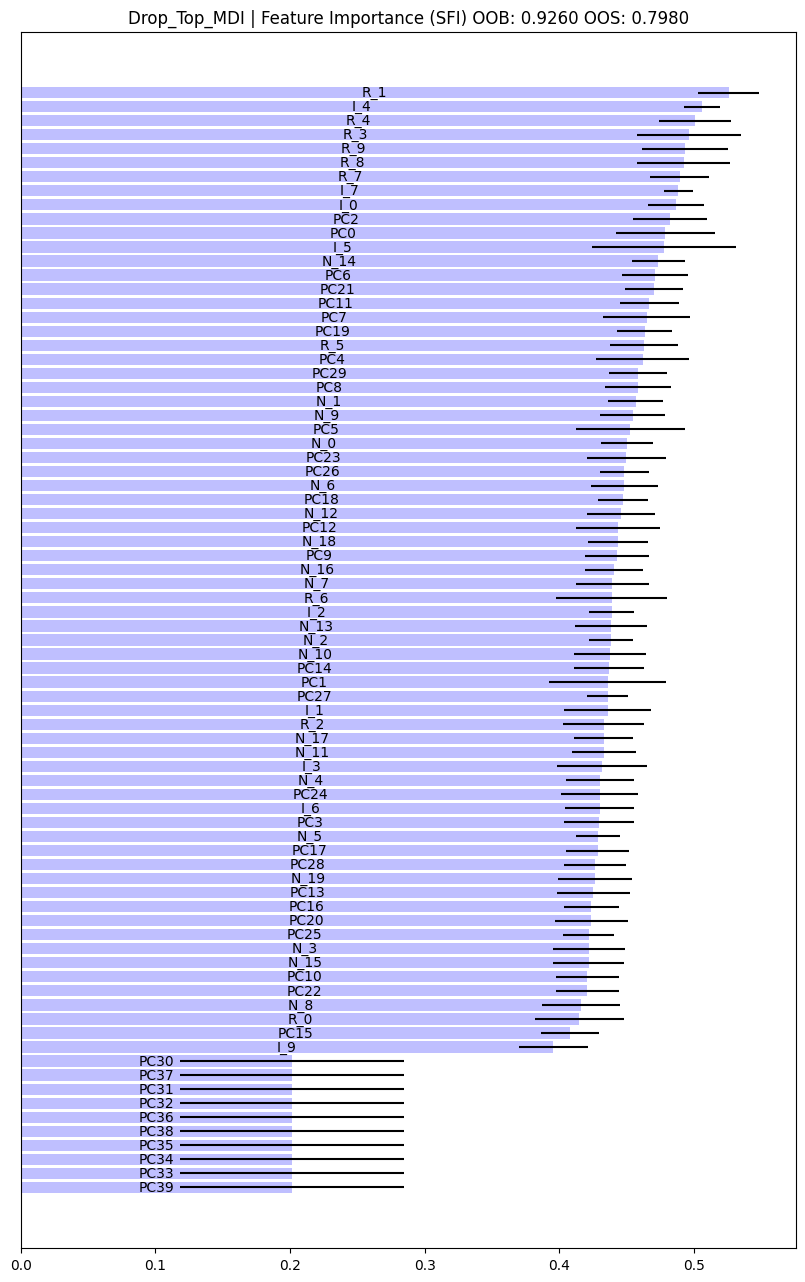


Computing feature importance on Drop_Top_MDA dataset
MDI_accuracy_0.00_1.0


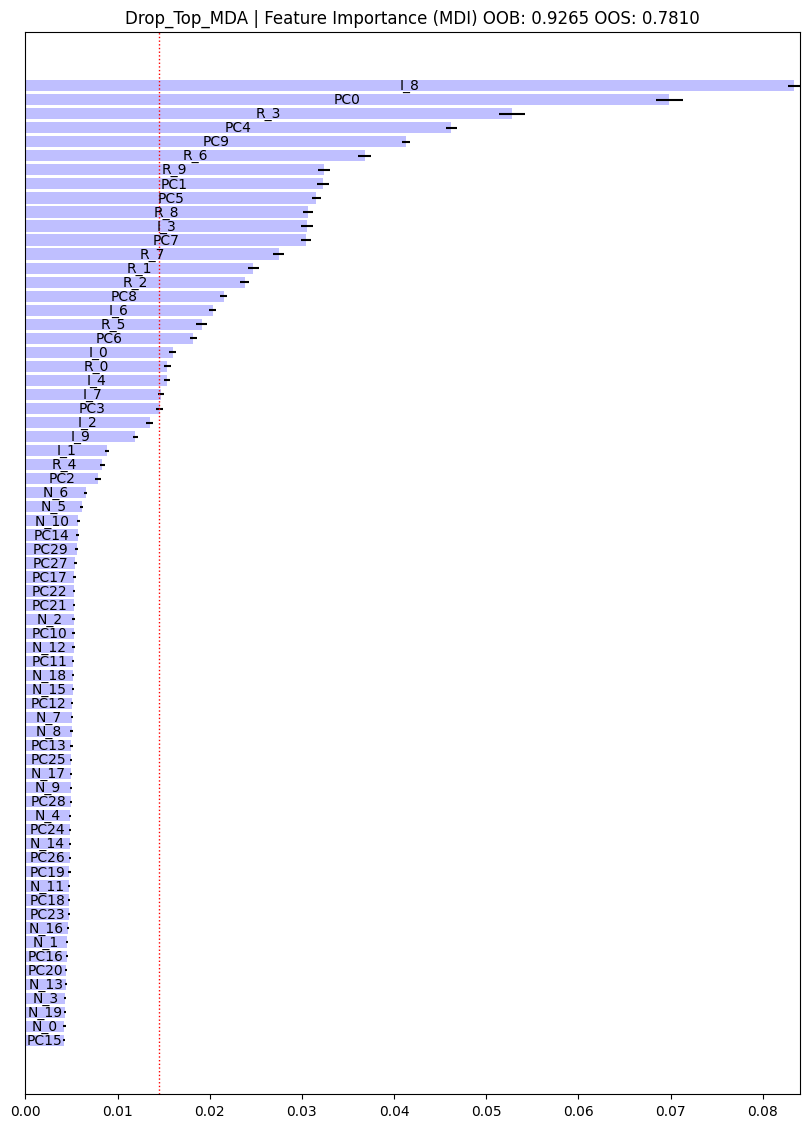

MDA_accuracy_0.00_1.0


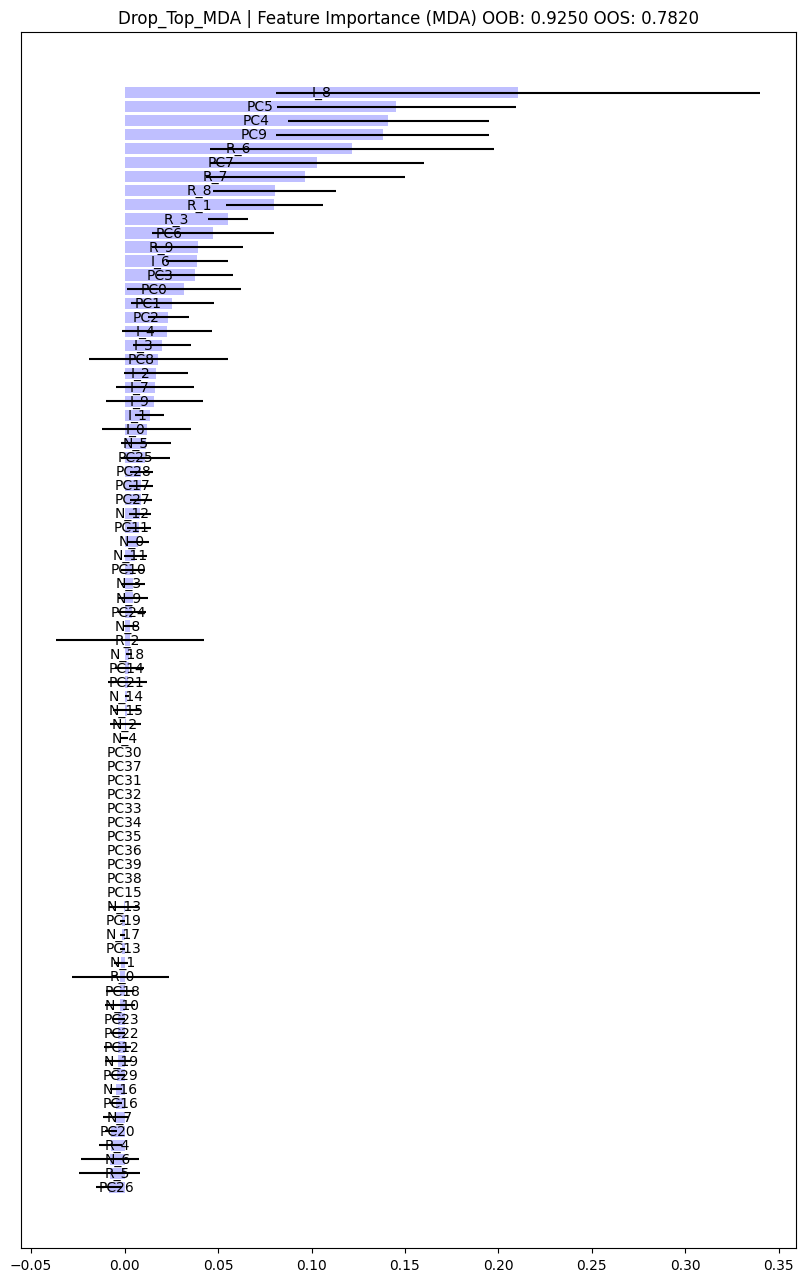

SFI_accuracy_0.00_1.0


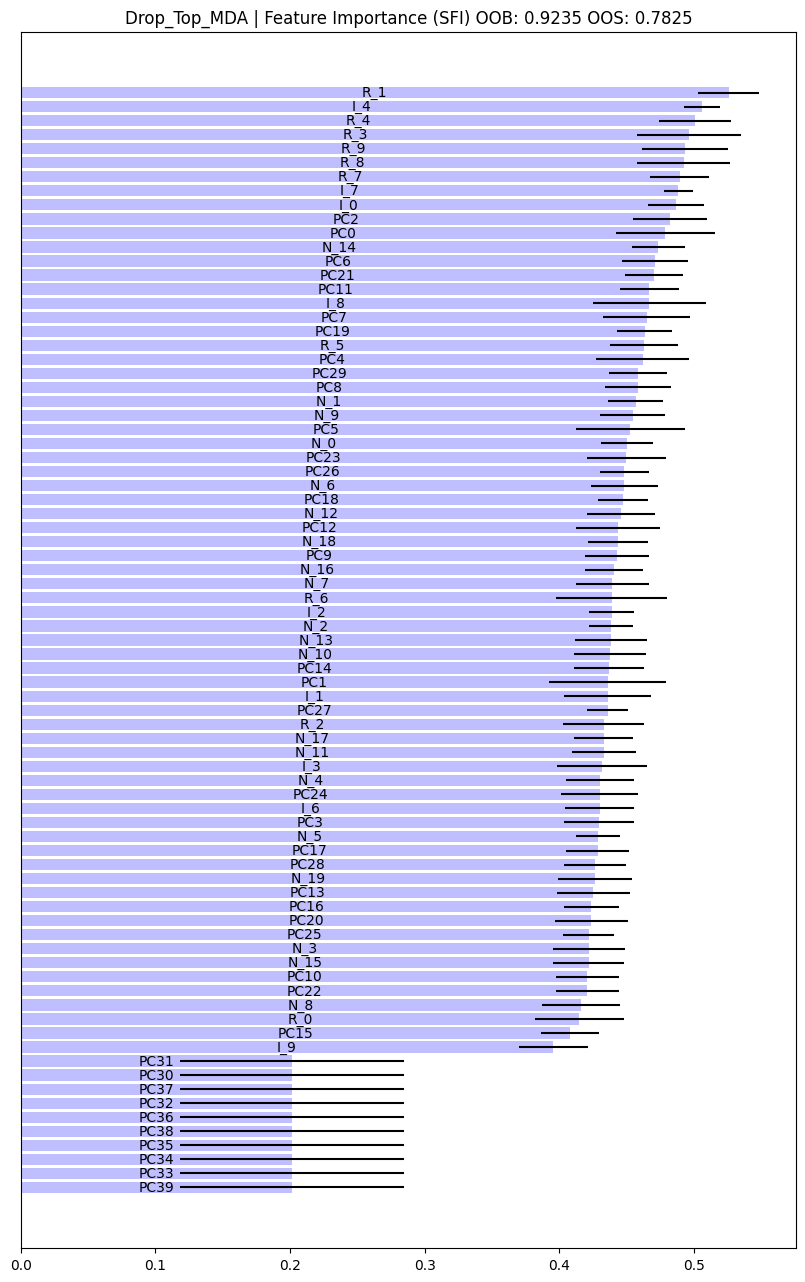


Computing feature importance on Drop_Top_SFI dataset
MDI_accuracy_0.00_1.0


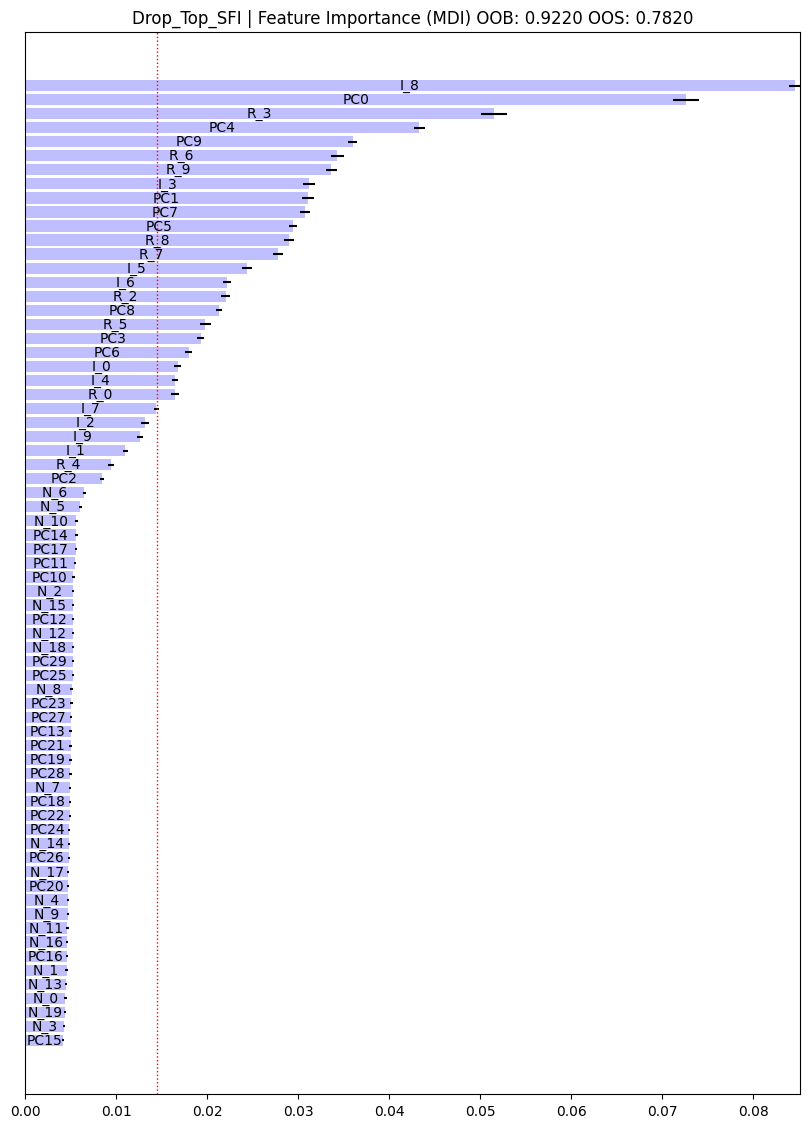

MDA_accuracy_0.00_1.0


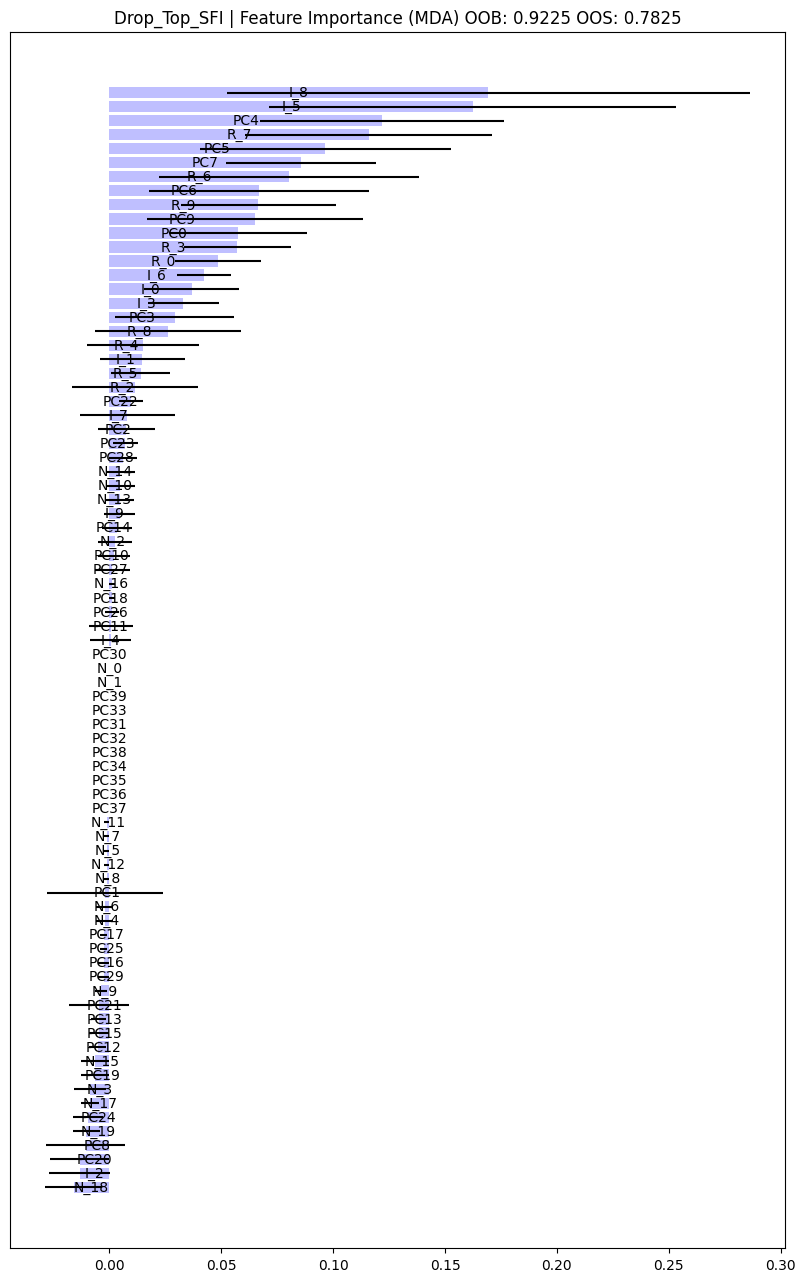

SFI_accuracy_0.00_1.0


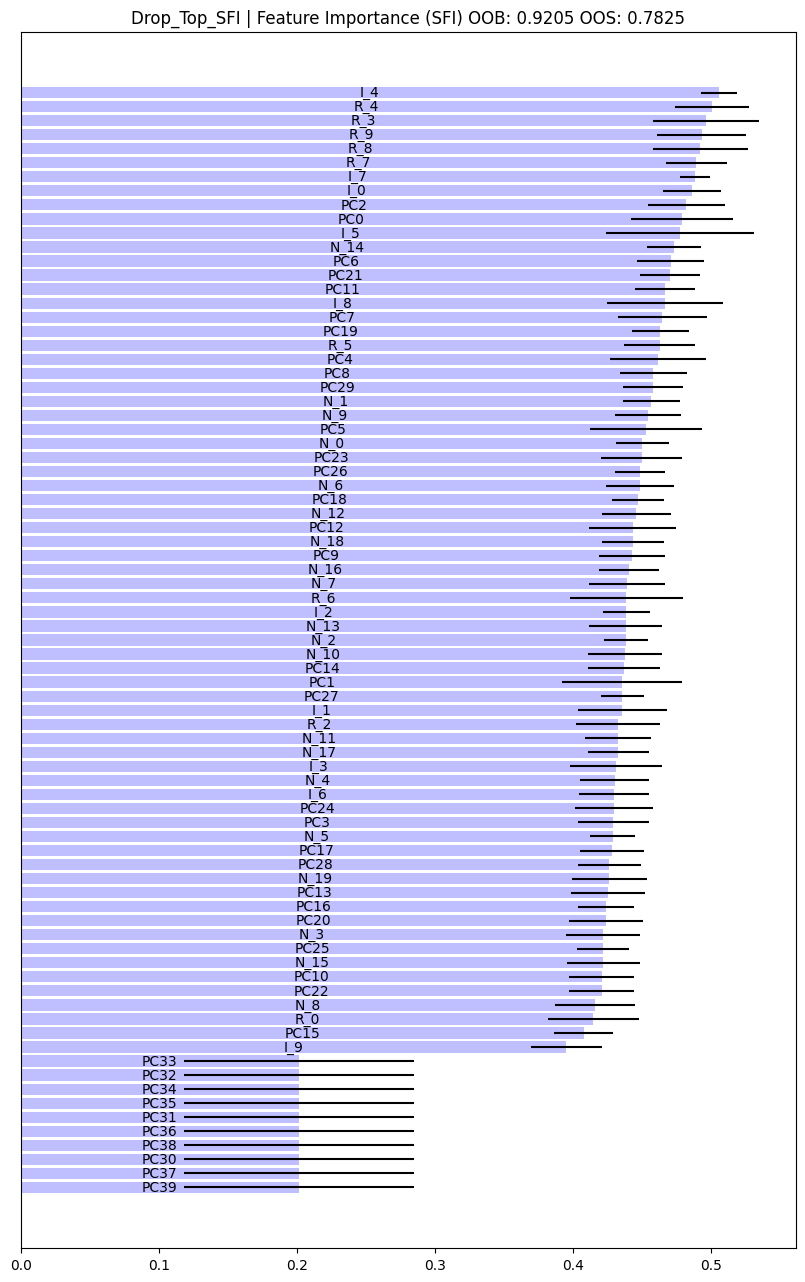

In [16]:
# Create reduced datasets by dropping top features from each method
X_dd_no_MDI = X_dd.drop(columns=[top_features['MDI']]) if 'MDI' in top_features else X_dd
X_dd_no_MDA = X_dd.drop(columns=[top_features['MDA']]) if 'MDA' in top_features else X_dd
X_dd_no_SFI = X_dd.drop(columns=[top_features['SFI']]) if 'SFI' in top_features else X_dd

print(f"Original X_dd shape: {X_dd.shape}")
print(f"X_dd_no_MDI shape (dropped {top_features.get('MDI', 'None')}): {X_dd_no_MDI.shape}")
print(f"X_dd_no_MDA shape (dropped {top_features.get('MDA', 'None')}): {X_dd_no_MDA.shape}")
print(f"X_dd_no_SFI shape (dropped {top_features.get('SFI', 'None')}): {X_dd_no_SFI.shape}")

# Now compute feature importance on each reduced dataset
reduced_datasets = {
    'Drop_Top_MDI': X_dd_no_MDI,
    'Drop_Top_MDA': X_dd_no_MDA,
    'Drop_Top_SFI': X_dd_no_SFI
}

for dataset_name, X_reduced in reduced_datasets.items():
    print(f"\n{'='*60}")
    print(f"Computing feature importance on {dataset_name} dataset")
    print(f"{'='*60}")
    
    dict0 = {'minWLeaf': [0.], 'scoring': ['accuracy'], 'method': ['MDI', 'MDA', 'SFI'], 'max_samples': [1.]}
    jobs = [dict(zip(dict0, i)) for i in product(*dict0.values())]
    
    for job in jobs:
        job['simNum'] = job['method'] + '_' + job['scoring'] + '_' + '%.2f' % job['minWLeaf'] + '_' + str(job['max_samples'])
        print(job['simNum'])
        
        imp, oob, oos = featImportance(trnsX=X_reduced, cont=cont, n_estimators=n_estimators, cv=cv, method=job['method'],
                                       scoring=job['scoring'], min_weight_fraction_leaf=job['minWLeaf'], max_samples=job['max_samples'])
        plotFeatImportance(imp=imp, oob=oob, oos=oos, method=job['method'], tag=dataset_name, simNum=job['simNum'])

### Original Union

MDI - I_8, PC0, R_3, PC4

MDA - I_5, I_8, PC9, PC5

SFI - R_1, I_4, R_4, R_3

### Dropping Top MDI (I_8)

MDI - PC0, R_9, R_3, R_6 ->

MDA - I_5, PC7, PC4, R_7 - **lost I_8**

SFI - R_1, I_4, R_4, R_3 - **unaffcted**

### Dropping Top MDA (I_5)

MDI - I_8, PC0, R_3, PC4 - **unaffcted**

MDA - I_8, PC5, PC4, PC9 ->

SFI - R_1, I_4, R_4, R_3 - **unaffcted**

### Dropping Top SFI (R_1)

MDI - I_8, PC0, R_3, PC4 - **unaffcted**

MDA - I_8, I_5, PC4, R_7 

SFI - I_4, R_4, R_3, R_9 -> same ordering minus top (R_1)